In [ ]:
# Create a model that can classify the species of IRIS flower
# based on flower's properties

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
data.variety.unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

In [5]:
data.describe()

,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


<Axes: ylabel='petal.length'>

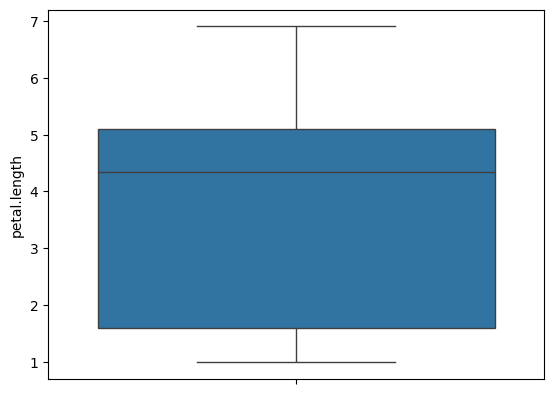

In [7]:
import seaborn as sns
sns.boxplot(data['petal.length'])

In [8]:
#Seperate data as features and label
features = data.iloc[:,[0,1,2,3]].values
label = data.iloc[:,[4]].values

In [9]:
#Model Exploration Phase ----- Dr.AI Strage ;)

import warnings
warnings.filterwarnings("ignore")

CL = 0.95

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

for rs in range(1,301):
  X_train,X_test,y_train,y_test = train_test_split(features,
                                                   label,
                                                   test_size=0.2,
                                                   random_state=rs)

  model = LogisticRegression()
  model.fit(X_train,y_train)

  trainScore = model.score(X_train,y_train)
  testScore = model.score(X_test,y_test)

  if testScore > trainScore and testScore>=CL:
    print(f"Test Score : {testScore} | Train Score: {trainScore} | RandomState: {rs}")

Test Score : 1.0 | Train Score: 0.9666666666666667 | RandomState: 3
Test Score : 1.0 | Train Score: 0.975 | RandomState: 9
Test Score : 1.0 | Train Score: 0.975 | RandomState: 10
Test Score : 1.0 | Train Score: 0.975 | RandomState: 15
Test Score : 1.0 | Train Score: 0.9666666666666667 | RandomState: 18
Test Score : 1.0 | Train Score: 0.9666666666666667 | RandomState: 19
Test Score : 1.0 | Train Score: 0.9666666666666667 | RandomState: 23
Test Score : 1.0 | Train Score: 0.9666666666666667 | RandomState: 24
Test Score : 0.9666666666666667 | Train Score: 0.9583333333333334 | RandomState: 26
Test Score : 1.0 | Train Score: 0.9583333333333334 | RandomState: 32
Test Score : 1.0 | Train Score: 0.9666666666666667 | RandomState: 34
Test Score : 1.0 | Train Score: 0.9666666666666667 | RandomState: 35
Test Score : 1.0 | Train Score: 0.975 | RandomState: 37
Test Score : 1.0 | Train Score: 0.9666666666666667 | RandomState: 38
Test Score : 1.0 | Train Score: 0.9833333333333333 | RandomState: 40
Test

In [10]:
#Prepare final Model

X_train,X_test,y_train,y_test = train_test_split(features,
                                                   label,
                                                   test_size=0.2,
                                                   random_state=72)

model = LogisticRegression()
model.fit(X_train,y_train)

trainScore = model.score(X_train,y_train)
testScore = model.score(X_test,y_test)

print(f"Test Score : {testScore} | Train Score: {trainScore} ")

Test Score : 1.0 | Train Score: 0.9833333333333333 


In [15]:
#Check w.r.t CL for entire dataset
# For any classification algo, model.score returns accuracy metric value

print(model.score(features,label))

CL = 0.95

if model.score(features,label) >= CL:
  print("Approve Model and Deploy the same")
else:
  print("Improve model")

Approve Model and Deploy the same


In [11]:
#Deploy Test
#5.1	3.5	1.4	0.2

model.predict(np.array([[5.1,3.5,1.4,0.2]]))

array(['Setosa'], dtype=object)

In [12]:
#Deploy Test
sepal_length = float(input("Enter Sepal Length: "))
sepal_width = float(input("Enter Sepal Width: "))
petal_length = float(input("Enter Petal Length: "))
petal_width = float(input("Enter Petal Width: "))
featureInput = np.array([[sepal_length,sepal_width,petal_length,petal_width]])
result = model.predict(featureInput)
print(f"The predicted species for the flower is: {result[0]}")

KeyboardInterrupt: Interrupted by user

In [ ]:
# Assignment
#
# Dataset: wine quality
#
# Create a mdoel that can check the quality of wine based on wine distillary properties
#
# SL = 0.3
# SL = 0.2
# SL = 0.1